In [52]:
"""
2D implementation of 
∂t phi_a= ∂x [D ∂x phi_a + phi_a(1-phi_a-phi_b)∂x pi_a +  sqrt(2D phi_a(1-phi_a-phi_b)) Z]
∂t phi_b= ∂x [D ∂x phi_b + phi_b(1-phi_a-phi_b)∂x pi_b +  sqrt(2D phi_b(1-phi_a-phi_b)) Z]
using a conservative finite-volume discretization and a stochastic (predictor-corrector) time integrator.

Features:
- Positivity floor for density
- multiplicative conservative noise (phi_a(1-phi_a-phi_b))
- Can be extended to the case with convolutional interaction potential using FFT (periodic)

Author: Tuan Pham and Wout Merbis
"""
import numpy as np
import matplotlib.pyplot as plt
from numpy.fft import rfft, irfft
from matplotlib.animation import FuncAnimation, PillowWriter
import FHD as fhd
import importlib

# importlib.reload(fhd)

In [53]:
N = 2**7
L = 50
simulator = fhd.fhd(L, N)

In [54]:
kappa_aa = kappa_bb = 1 # T
kappa_ab = - 1 #(T-1)
kappa_ba = - 1 # (T-1)
# coupling matrix kappa  for pi^{(a)} = sum_b kappa_ab * (V * phi_b)
kappa = np.array([[kappa_aa, kappa_ab],
                  [kappa_ba, kappa_bb]])
D = 0.1 # diffusion coefficient
Gamma = 1 # Utility nabla^3 term coefficient
b = 0.4  # birth coefficient
d = 0.1  # death coefficient

param = {'D': D, 'kappa': kappa, 'Gamma': Gamma, 'b': b, 'd': d}

x = simulator.x
nspecies = simulator.nspecies

phi = np.zeros((nspecies, N))
phi0 = 0.4
pert_amp = 0.2
phi[0,:] =phi0 + pert_amp * np.cos(2*np.pi*x / L * 2) + 0.0 * np.random.normal(size=N) 
#phi0 + pert_amp * np.cos(2*np.pi*x / L * 6) + 0.005 * np.random.normal(size=N) 
# np.exp(-(x+L//8)**2/(2*(L//12)**2)) 
#  0.5*(np.tanh(-x)+1)/2
phi[1,:] = phi0 + pert_amp * np.sin(2*np.pi*x / L * 2) + 0.0 * np.random.normal(size=N) 
#phi0 + pert_amp * np.sin(2*np.pi*x / L * 6) + 0.005 * np.random.normal(size=N) 
# np.exp(-(x-L//8)**2/(2*(L//12)**2)) 
# 0.5*(np.tanh(x)+1)/2


Step 2000/200000: mean rho = 0.363466, min = 7.760009e-02
Step 4000/200000: mean rho = 0.368890, min = 6.088830e-02
Step 6000/200000: mean rho = 0.370644, min = 5.851590e-02
Step 8000/200000: mean rho = 0.371717, min = 2.997843e-02
Step 10000/200000: mean rho = 0.371607, min = 3.366217e-02
Step 12000/200000: mean rho = 0.372662, min = 2.000419e-02
Step 14000/200000: mean rho = 0.375668, min = 3.158065e-02
Step 16000/200000: mean rho = 0.376809, min = 2.515202e-02
Step 18000/200000: mean rho = 0.376368, min = 1.294140e-02
Step 20000/200000: mean rho = 0.376233, min = 9.059301e-03
Step 22000/200000: mean rho = 0.375581, min = 1.493165e-02
Step 24000/200000: mean rho = 0.376034, min = 3.208389e-02
Step 26000/200000: mean rho = 0.378640, min = 6.045598e-03
Step 28000/200000: mean rho = 0.377705, min = 1.000000e-10
Step 30000/200000: mean rho = 0.377521, min = 3.213464e-03
Step 32000/200000: mean rho = 0.377869, min = 1.615388e-02
Step 34000/200000: mean rho = 0.378079, min = 1.488271e-02
S

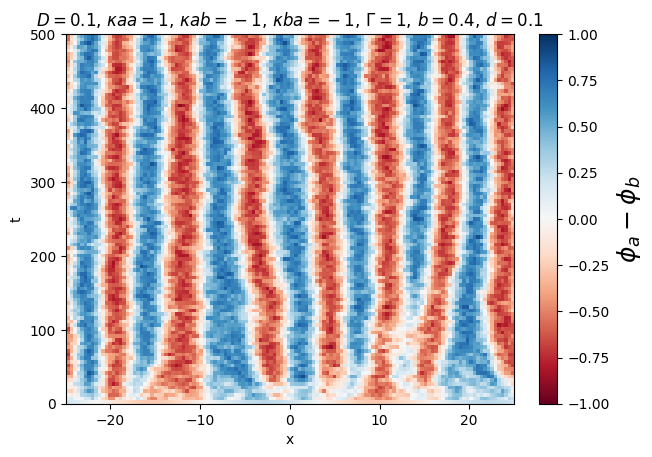

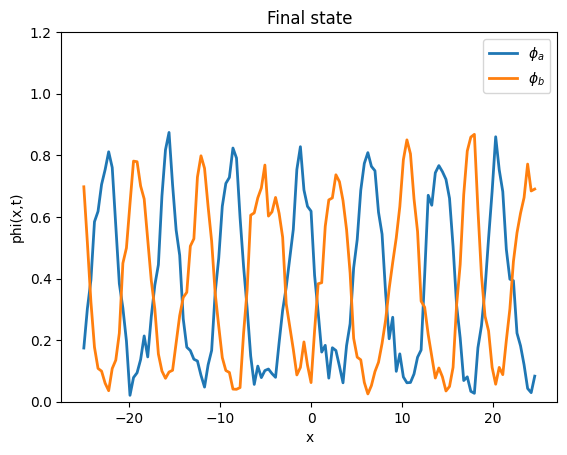

In [64]:
dt = 0.0025 
nsteps = 200000
noise = 1
frames = 100

phi_run = simulator.run(phi, param, nsteps, dt, noise, frames)

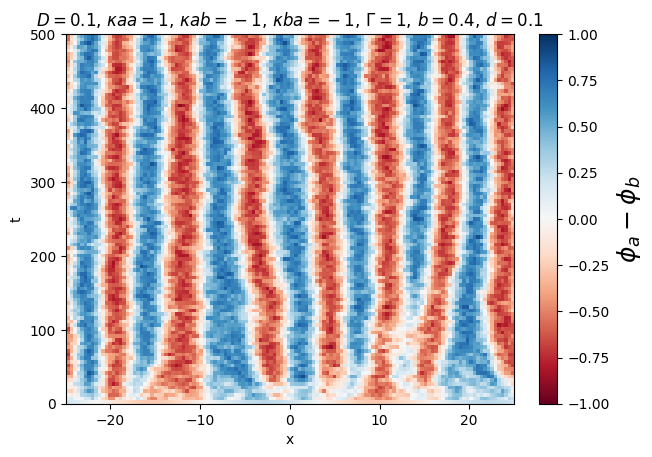

In [65]:
phi_diff = phi_run[0,:,:] - phi_run[1,:,:]
# t = np.linspace(0,dt*nsteps, plot_every+1)
im =plt.imshow(phi_diff, cmap = 'RdBu', aspect='auto', origin='lower', extent=[-L/2,L/2,0,dt*nsteps], vmin=-1, vmax=1)
plt.title(fr"$D = {D},\, \kappa aa = {kappa_aa},\, \kappa ab = {kappa_ab},\, \kappa ba = {kappa_ba},\, \Gamma = { Gamma}, \, b={b}, \, d={d} $")
plt.xlabel("x")
plt.ylabel("t")
cbar = plt.colorbar(im, fraction=0.046)
cbar.set_label(r"$\phi_a - \phi_b$",size=18)
# plt.savefig("fhd_plots/integrating_tanh_noisy_reactions.pdf")
plt.show()


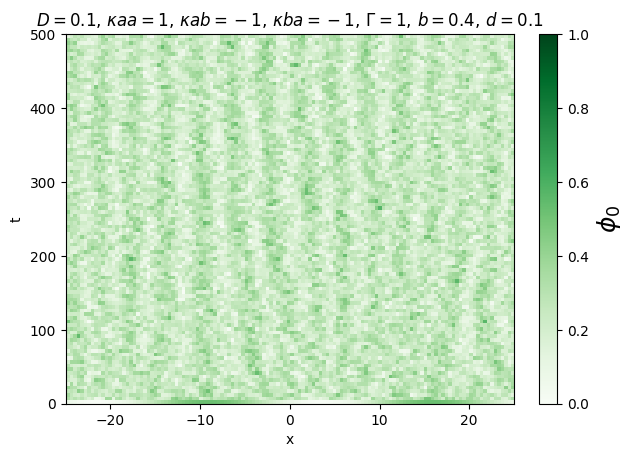

In [66]:
phi0 = 1 - phi_run[0,:,:] - phi_run[1,:,:]
# t = np.linspace(0,dt*nsteps, plot_every+1)
im =plt.imshow(phi0, cmap = 'Greens', aspect='auto', origin='lower', extent=[-L/2,L/2,0,dt*nsteps], vmin=0, vmax=1)
plt.title(fr"$D = {D},\, \kappa aa = {kappa_aa},\, \kappa ab = {kappa_ab},\, \kappa ba = {kappa_ba},\, \Gamma = { Gamma}, \, b={b}, \, d={d} $")
plt.xlabel("x")
plt.ylabel("t")
cbar = plt.colorbar(im, fraction=0.046)
cbar.set_label(r"$\phi_0$",size=18)
# plt.savefig("fhd_plots/phi0_integrated_tanh_with_noise.pdf")
plt.show()


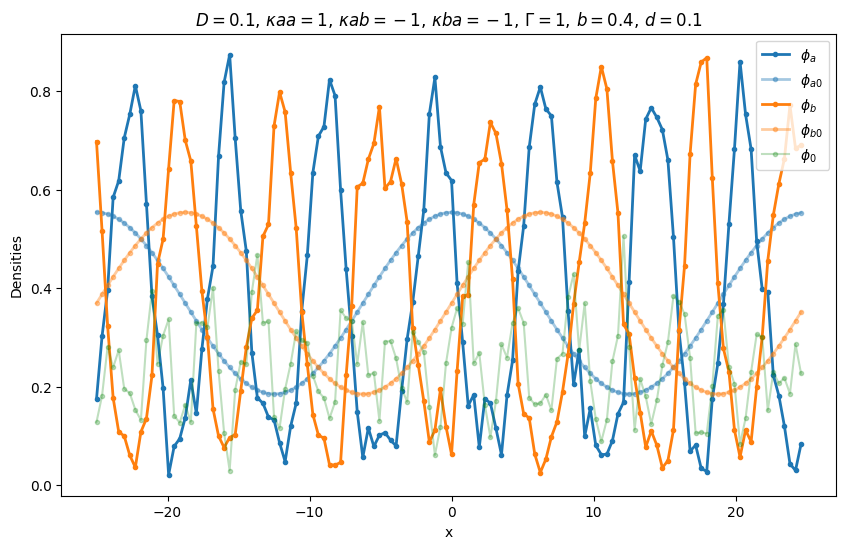

In [67]:
fig, ax = plt.subplots(figsize=(10,6))
ep = -1
line_phi = []
colors = ['C0', 'C1']
labels = [r'$\phi_a$', r'$\phi_b$']
labelnew = [r'$\phi_a$', r'$\phi_b$', r'$\phi_a + \phi_b$']
for a in range(nspecies):
    ln, = ax.plot(x, phi_run[a,ep], lw=2, color=colors[a], label=labels[a], marker = '.')
    ln, = ax.plot(x, phi_run[a,0], lw=2, color=colors[a], label=labels[a]+"${}_0$", marker = '.', alpha=0.4)
    line_phi.append(ln)
#line_phi.append(ax.plot(x, phi_tot, lw=2,c='k', label=labelnew[2]))
ax.plot(x, 1-phi_run[:,ep,:].sum(axis=0), color = 'g', label= r'$\phi_0$', marker = '.', alpha=0.25)
# ax.set_ylim(1e-8, 1.05)
ax.set_xlabel('x')
# ax.set_yscale('log')
plt.title(fr"$D = {D},\, \kappa aa = {kappa_aa},\, \kappa ab = {kappa_ab},\, \kappa ba = {kappa_ba},\, \Gamma = { Gamma}, \, b={b}, \, d={d} $")
ax.set_ylabel('Densities')
ax.legend()
plt.show()


In [ ]:
import matplotlib.animation as animation
from IPython.display import HTML


t = phi_run.shape[1]  # Number of time steps


# Create figure and axis
fig, ax = plt.subplots(figsize=(10, 6))
line_phi = []
colors = ['C0', 'C1', 'C2']
labels = [r'$\phi_a$', r'$\phi_b$', r'$\phi_0$']

# Initialize the plot lines
for a in range(2):
    ln, = ax.plot(x, phi_run[a,0], lw=2, color=colors[a], label=labels[a], marker='.')
    line_phi.append(ln)

phi0 =  1-phi_run[:,0].sum(axis=0)
ln, = ax.plot(x, phi0, lw =2, color = colors[2], label = labels[2], marker = '.')
line_phi.append(ln)

ax.set_ylim([0,1])
ax.set_xlabel('x')
ax.set_ylabel('Densities')
ax.legend(loc = "upper right")

# Title with parameters
title = fr"$D = {D},\, \kappa aa = {kappa_aa},\, \kappa ab = {kappa_ab},\, \kappa ba = {kappa_ba},\, \Gamma = {Gamma}, \, b={b}, \, d={d} $"
plt.title(title)

# Update function for animation
def update(frame):
    for a in range(2):
        line_phi[a].set_data(x, phi_run[a, frame])
    line_phi[2].set_data(x, 1- phi_run[:,frame].sum(axis=0))
    return line_phi

# Create animation
ani = animation.FuncAnimation(fig, update, frames=t, blit=True)

# Save animation as GIF
# ani.save('fhd_plots/migrating_long_run.gif', writer='pillow')
HTML(ani.to_jshtml())
